## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [2]:
# Instalo las librerías necesarias para trabajar con redes neuronales, imágenes médicas y métricas de evaluación.
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

## 3. Cargar el dataset médico (BreastMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

En este ejercicio utilizaremos **BreastMNIST**:
- Entrada: ecografías de mama 2D en escala de grises.
- Tipo de problema: clasificación binaria.
- Etiquetas: **0 = maligno** y **1 = normal o benigno**.
- Particiones: train, validation y test ya definidas.

In [3]:
# Importo las librerías que voy a utilizar y selecciono BreastMNIST como el dataset del trabajo.
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [4]:
# Transformo las imágenes a tensores y cargo los conjuntos de entrenamiento, validación y prueba.
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)

100%|██████████| 560k/560k [00:01<00:00, 501kB/s]


(546, 78, 156)

### 3.1. Visualizar ejemplos

Antes de entrenar el modelo, observamos varias ecografías para conocer el aspecto de las imágenes y verificar sus etiquetas.

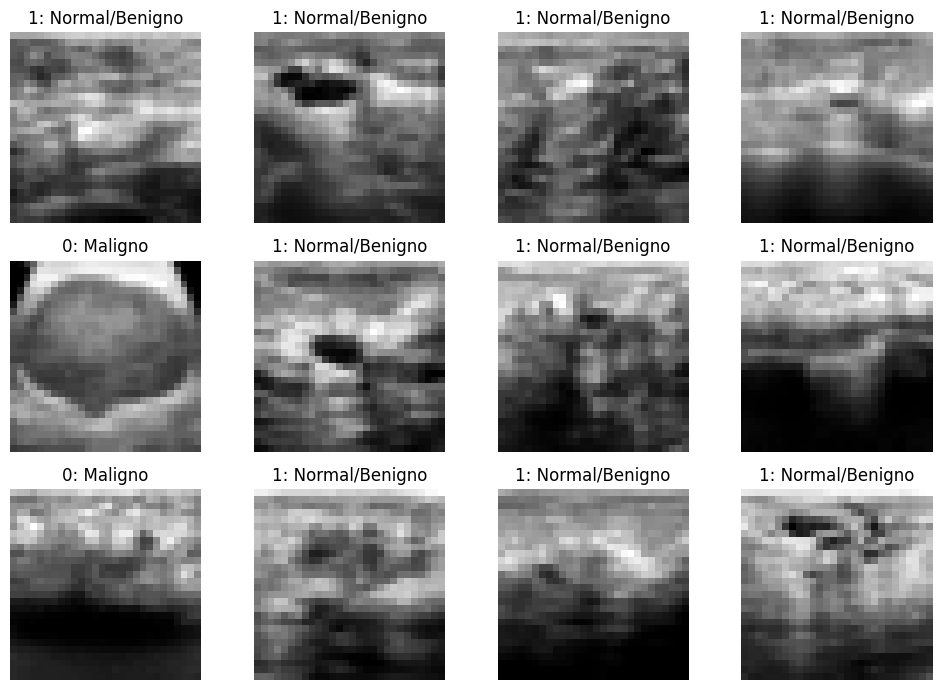

In [5]:
# Muestro algunas imágenes del dataset junto con sus etiquetas para ver con qué tipo de ecografías voy a trabajar.
def show_batch(dataset, n=12):
    nombres = {0: "Maligno", 1: "Normal/Benigno"}
    plt.figure(figsize=(10, 7))

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)
        img = x.squeeze(0)

        etiqueta = int(y.item())
        plt.imshow(img, cmap="gray")
        plt.title(f"{etiqueta}: {nombres[etiqueta]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [6]:
# Reviso si hay una GPU disponible para usarla durante el entrenamiento; si no, se utiliza el procesador.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [20]:
# Creo los DataLoader para enviar las imágenes al modelo por grupos y mezclar los datos de entrenamiento.
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Primero construiremos una CNN sencilla sin utilizar pesos preentrenados.

La red tendrá:
- Capas convolucionales.
- Activación ReLU.
- MaxPooling.
- Un clasificador final para distinguir las dos clases de BreastMNIST.

In [8]:
# Creo la arquitectura de la CNN que va a extraer características de las imágenes y realizar la clasificación final.
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

Para evaluar la clasificación utilizaremos:
- **Accuracy**: porcentaje de predicciones correctas.
- **ROC-AUC**: capacidad del modelo para separar las dos clases.
- **Matriz de confusión**.
- **Precision, Recall y F1-score**.

Después definiremos las funciones que se usarán durante el entrenamiento.

In [9]:
# Creo las funciones que voy a utilizar para entrenar y evaluar los modelos y calcular sus métricas.
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [22]:
# Defino la función de pérdida, el optimizador y entreno la CNN durante varias épocas guardando sus resultados.
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-5
)

epochs = 50
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.5051 | val_acc=0.7308 | val_auc=0.7034
Epoch 02 | train_loss=0.5119 | val_acc=0.7308 | val_auc=0.7034
Epoch 03 | train_loss=0.5039 | val_acc=0.7308 | val_auc=0.7034
Epoch 04 | train_loss=0.5385 | val_acc=0.7308 | val_auc=0.7034
Epoch 05 | train_loss=0.5020 | val_acc=0.7308 | val_auc=0.7034
Epoch 06 | train_loss=0.5262 | val_acc=0.7308 | val_auc=0.7034
Epoch 07 | train_loss=0.5198 | val_acc=0.7308 | val_auc=0.7034
Epoch 08 | train_loss=0.5149 | val_acc=0.7308 | val_auc=0.7034
Epoch 09 | train_loss=0.5114 | val_acc=0.7308 | val_auc=0.7043
Epoch 10 | train_loss=0.5111 | val_acc=0.7308 | val_auc=0.7043
Epoch 11 | train_loss=0.5521 | val_acc=0.7308 | val_auc=0.7043
Epoch 12 | train_loss=0.4994 | val_acc=0.7308 | val_auc=0.7034
Epoch 13 | train_loss=0.5218 | val_acc=0.7308 | val_auc=0.7034
Epoch 14 | train_loss=0.5021 | val_acc=0.7308 | val_auc=0.7034
Epoch 15 | train_loss=0.5257 | val_acc=0.7308 | val_auc=0.7034
Epoch 16 | train_loss=0.5094 | val_acc=0.7308 | val_auc

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


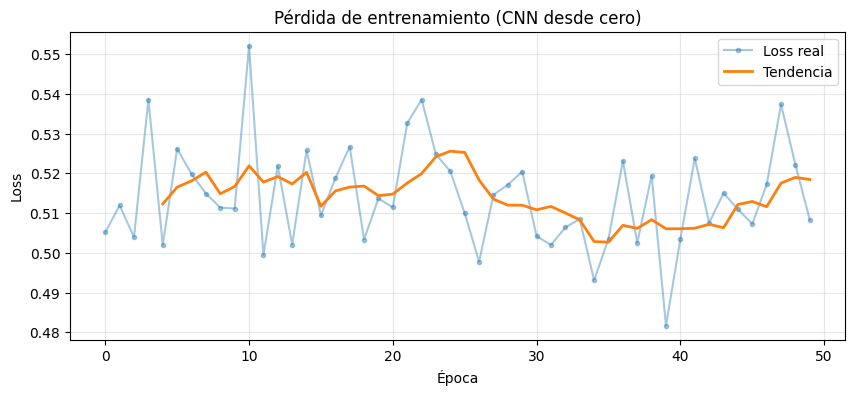

In [25]:
# Grafico la pérdida real y una línea suavizada para observar mejor la tendencia.
loss = np.array(history_scratch["train_loss"])

window = 5

loss_suave = np.convolve(
    loss,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["train_loss"],
    marker="o",
    markersize=3,
    alpha=0.4,
    label="Loss real"
)

plt.plot(
    range(window - 1, len(loss)),
    loss_suave,
    linewidth=2,
    label="Tendencia"
)

plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 5.4. Evaluación final en test

Evaluamos la CNN con el conjunto de **test**, que no fue utilizado para entrenar el modelo.

In [26]:
# Evalúo la CNN con el conjunto de prueba y calculo sus principales métricas y la matriz de confusión.
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.7308
Test ROC-AUC:  0.7364

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        42
           1     0.7308    1.0000    0.8444       114

    accuracy                         0.7308       156
   macro avg     0.3654    0.5000    0.4222       156
weighted avg     0.5340    0.7308    0.6171       156



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[  0,  42],
       [  0, 114]])

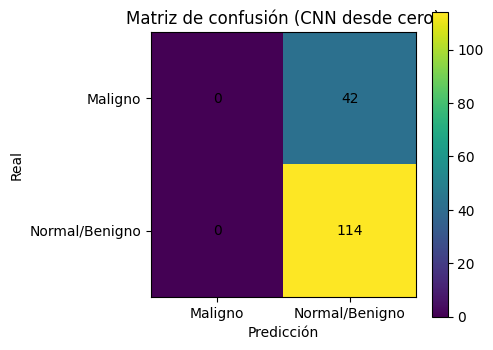

In [27]:
# Muestro gráficamente la matriz de confusión para ver los aciertos y errores del modelo.
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], ["Maligno", "Normal/Benigno"])
plt.yticks([0, 1], ["Maligno", "Normal/Benigno"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## 6. Data Augmentation (aumento de datos)

El **data augmentation** crea pequeñas variaciones de las imágenes de entrenamiento para ayudar al modelo a generalizar.

En este notebook aplicaremos:
- Rotaciones pequeñas.
- Traslaciones suaves.

Luego entrenaremos nuevamente la misma CNN y compararemos sus resultados con el modelo sin aumento de datos.

In [28]:
# Aplico Data Augmentation mediante pequeñas rotaciones y desplazamientos para aumentar la variedad de imágenes.
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [29]:
# Creo y entreno una nueva CNN utilizando los datos con Data Augmentation.
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6647 | val_acc=0.7308 | val_auc=0.5104
Epoch 02 | train_loss=0.6144 | val_acc=0.7308 | val_auc=0.5255
Epoch 03 | train_loss=0.5648 | val_acc=0.7308 | val_auc=0.5288
Epoch 04 | train_loss=0.5791 | val_acc=0.7308 | val_auc=0.5322
Epoch 05 | train_loss=0.5708 | val_acc=0.7308 | val_auc=0.5355
Epoch 06 | train_loss=0.5868 | val_acc=0.7308 | val_auc=0.5330


### 6.1. Comparación rápida


In [30]:
# Evalúo la CNN con Data Augmentation y comparo sus resultados con los de la CNN original.
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

Sin augmentation  | test_acc=0.7308 | test_auc=0.7364
Con augmentation  | test_acc=0.7308 | test_auc=0.5929


## 7. Transfer Learning en ecografías de mama

El **transfer learning** reutiliza un modelo que ya fue entrenado con una gran cantidad de imágenes y lo adapta a una nueva tarea.

Aquí utilizaremos **ResNet18** preentrenada con ImageNet.

Como BreastMNIST contiene imágenes en escala de grises:
1. Redimensionaremos las imágenes a 224 × 224.
2. Repetiremos el canal gris para obtener 3 canales.
3. Reemplazaremos la última capa de ResNet18 para clasificar las dos clases de BreastMNIST.
4. Primero entrenaremos la capa final y después haremos fine-tuning de las últimas capas.

In [31]:
# Preparo las imágenes para ResNet18 cambiando su tamaño y adaptándolas al formato que necesita este modelo.
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [32]:
# Cargo ResNet18 con pesos preentrenados, congelo sus capas y cambio la última capa para mis dos clases.
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [33]:
# Entreno solamente la última capa de ResNet18 aprovechando las características que el modelo ya había aprendido.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage1 Epoch 01 | train_loss=0.6353 | val_acc=0.7308 | val_auc=0.4244
Stage1 Epoch 02 | train_loss=0.5845 | val_acc=0.7308 | val_auc=0.4937
Stage1 Epoch 03 | train_loss=0.5543 | val_acc=0.7308 | val_auc=0.4921
Stage1 Epoch 04 | train_loss=0.5462 | val_acc=0.7308 | val_auc=0.5372


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [34]:
# Descongelo la última parte de ResNet18 para poder realizar Fine-Tuning y adaptarlo mejor a las ecografías.
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)

17

In [35]:
# Continúo entrenando ResNet18 con un learning rate más pequeño para ajustar sus pesos de forma más controlada.
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage2 Epoch 01 | train_loss=0.4848 | val_acc=0.7821 | val_auc=0.7987
Stage2 Epoch 02 | train_loss=0.3586 | val_acc=0.8462 | val_auc=0.8872
Stage2 Epoch 03 | train_loss=0.3206 | val_acc=0.8590 | val_auc=0.9173
Stage2 Epoch 04 | train_loss=0.2688 | val_acc=0.8846 | val_auc=0.9457


### 7.3. Evaluación en test del modelo con transfer learning


In [36]:
# Evalúo ResNet18 después del Fine-Tuning usando el conjunto de prueba y calculo sus métricas.
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.8718 | test_auc=0.9160

              precision    recall  f1-score   support

           0     0.8929    0.5952    0.7143        42
           1     0.8672    0.9737    0.9174       114

    accuracy                         0.8718       156
   macro avg     0.8800    0.7845    0.8158       156
weighted avg     0.8741    0.8718    0.8627       156



array([[ 25,  17],
       [  3, 111]])

### 7.4. Comparación global (resumen)


In [37]:
# Comparo los resultados obtenidos por la CNN original, la CNN con Data Augmentation y ResNet18.
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.7308 | auc=0.7364
CNN desde cero (con aug)  | acc=0.7308 | auc=0.5929
Transfer learning (ResNet) | acc=0.8718 | auc=0.9160


## 8. Interpretabilidad básica: Grad-CAM

**Grad-CAM** permite visualizar qué regiones de una ecografía influyeron más en la predicción del modelo.

El resultado es un mapa de calor que se superpone sobre la imagen original. Esto ayuda a observar dónde está prestando atención la red, aunque no constituye una explicación clínica definitiva.

In [38]:
# Creo la función de Grad-CAM para identificar qué zonas de la imagen fueron importantes para la predicción.
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


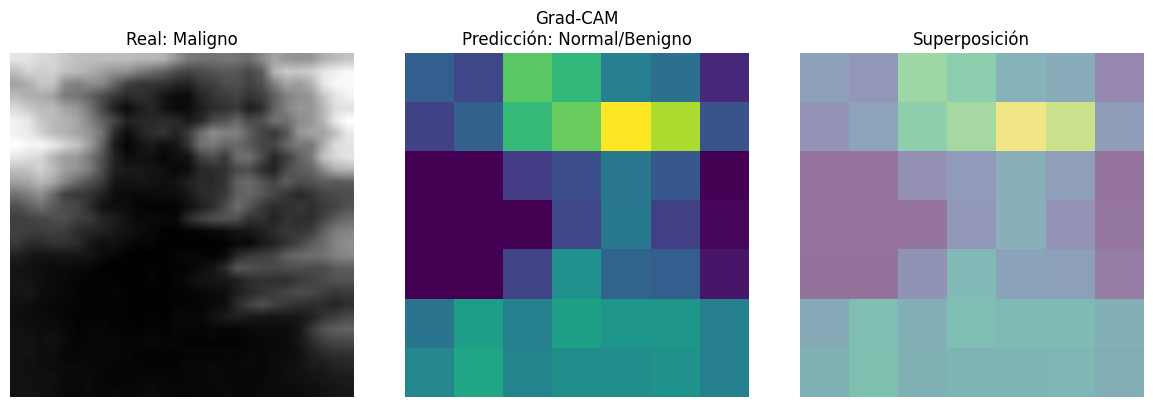

In [39]:
# Aplico Grad-CAM a una imagen de prueba y muestro la ecografía, el mapa de calor y la superposición de ambos.
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

nombres = {0: "Maligno", 1: "Normal/Benigno"}
real_class = int(y.item())

img = x[0].numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Real: {nombres[real_class]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM\nPredicción: {nombres[pred_class]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Buenas prácticas en clasificación de imágenes médicas

1. Mantener separados los conjuntos de train, validation y test.

2. No evaluar el modelo solamente con Accuracy:
- Revisar Recall, Precision, F1-score y ROC-AUC.
- Observar la matriz de confusión.

3. Evitar aumentos de datos demasiado agresivos que puedan alterar información importante de la ecografía.

4. Comparar una CNN entrenada desde cero con transfer learning.

5. Usar Grad-CAM como apoyo para interpretar qué zonas utiliza el modelo.

6. Recordar que los resultados de este notebook son educativos y no equivalen a una validación clínica.

## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [40]:
# Guardo los pesos de los modelos entrenados para poder volver a utilizarlos sin tener que entrenarlos otra vez.
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/breast_cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/breast_cnn_aug.pth")
torch.save(resnet.state_dict(), "models/breast_resnet_transfer.pth")

[
    "models/breast_cnn_scratch.pth",
    "models/breast_cnn_aug.pth",
    "models/breast_resnet_transfer.pth"
]

['models/breast_cnn_scratch.pth',
 'models/breast_cnn_aug.pth',
 'models/breast_resnet_transfer.pth']

## 11. Desarrollo de los ejercicios de la actividad

A continuación completo los ejercicios propuestos en el notebook original. El cambio de dataset ya se realizó usando **BreastMNIST**, por lo que ahora completo los experimentos de arquitectura, learning rate y scheduler, aumentos de datos y calibración con curvas ROC.

### 11.1. Ejercicio 1: cambiar la arquitectura de la CNN

En esta parte mejoro la CNN agregando **BatchNorm**, **Dropout** y más filtros.  
La idea es comparar una arquitectura un poco más completa con la CNN básica que usé al inicio.


In [41]:
# Creo una CNN mejorada agregando BatchNorm, Dropout y más filtros para probar una arquitectura más completa.
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_improved = ImprovedCNN(num_classes=num_classes).to(device)
model_improved


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [42]:
# Entreno la CNN mejorada para después comparar sus resultados con la CNN básica.
criterion_improved = nn.CrossEntropyLoss()
optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=1e-3)

epochs_improved = 8
history_improved = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs_improved + 1):
    train_loss = train_one_epoch(
        model_improved,
        train_loader,
        optimizer_improved,
        criterion_improved
    )

    val_acc, val_auc, _, _, _ = evaluate(model_improved, val_loader)

    history_improved["train_loss"].append(train_loss)
    history_improved["val_acc"].append(val_acc)
    history_improved["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )


Epoch 01 | train_loss=0.6018 | val_acc=0.7308 | val_auc=0.7201
Epoch 02 | train_loss=0.4926 | val_acc=0.7308 | val_auc=0.7711
Epoch 03 | train_loss=0.4590 | val_acc=0.6410 | val_auc=0.6658
Epoch 04 | train_loss=0.4491 | val_acc=0.2821 | val_auc=0.7126
Epoch 05 | train_loss=0.4109 | val_acc=0.3846 | val_auc=0.7143
Epoch 06 | train_loss=0.3972 | val_acc=0.5256 | val_auc=0.8003
Epoch 07 | train_loss=0.3980 | val_acc=0.4359 | val_auc=0.7619
Epoch 08 | train_loss=0.3365 | val_acc=0.2692 | val_auc=0.8454


In [43]:
# Evalúo la CNN mejorada y comparo sus métricas con las obtenidas por la CNN original.
test_acc_improved, test_auc_improved, y_true_improved, y_pred_improved, y_prob_improved = evaluate(
    model_improved,
    test_loader
)

print(f"CNN original  | Accuracy={test_acc:.4f} | ROC-AUC={test_auc:.4f}")
print(f"CNN mejorada  | Accuracy={test_acc_improved:.4f} | ROC-AUC={test_auc_improved:.4f}")


CNN original  | Accuracy=0.7308 | ROC-AUC=0.7364
CNN mejorada  | Accuracy=0.2692 | ROC-AUC=0.8133


### 11.2. Ejercicio 2: experimentar con learning rate y scheduler

Ahora pruebo otro `learning rate` y utilizo un **scheduler**.  
El scheduler reduce poco a poco el learning rate durante el entrenamiento para que los últimos ajustes del modelo sean más pequeños.


In [44]:
# Creo otra CNN mejorada y uso un learning rate diferente junto con un scheduler que lo reduce cada tres épocas.
model_scheduler = ImprovedCNN(num_classes=num_classes).to(device)

criterion_scheduler = nn.CrossEntropyLoss()
optimizer_scheduler = torch.optim.Adam(model_scheduler.parameters(), lr=5e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer_scheduler,
    step_size=3,
    gamma=0.5
)

epochs_scheduler = 8
history_scheduler = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

for epoch in range(1, epochs_scheduler + 1):
    current_lr = optimizer_scheduler.param_groups[0]["lr"]

    train_loss = train_one_epoch(
        model_scheduler,
        train_loader,
        optimizer_scheduler,
        criterion_scheduler
    )

    val_acc, val_auc, _, _, _ = evaluate(model_scheduler, val_loader)

    history_scheduler["train_loss"].append(train_loss)
    history_scheduler["val_acc"].append(val_acc)
    history_scheduler["val_auc"].append(val_auc)
    history_scheduler["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d} | "
        f"lr={current_lr:.6f} | "
        f"loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

    scheduler.step()


Epoch 01 | lr=0.000500 | loss=0.6006 | val_acc=0.2692 | val_auc=0.6608
Epoch 02 | lr=0.000500 | loss=0.5348 | val_acc=0.2692 | val_auc=0.6600
Epoch 03 | lr=0.000500 | loss=0.4904 | val_acc=0.2692 | val_auc=0.7009
Epoch 04 | lr=0.000250 | loss=0.4688 | val_acc=0.2692 | val_auc=0.7126
Epoch 05 | lr=0.000250 | loss=0.4729 | val_acc=0.2692 | val_auc=0.7293
Epoch 06 | lr=0.000250 | loss=0.4642 | val_acc=0.2692 | val_auc=0.7611
Epoch 07 | lr=0.000125 | loss=0.4243 | val_acc=0.2692 | val_auc=0.7811
Epoch 08 | lr=0.000125 | loss=0.4389 | val_acc=0.2949 | val_auc=0.7987


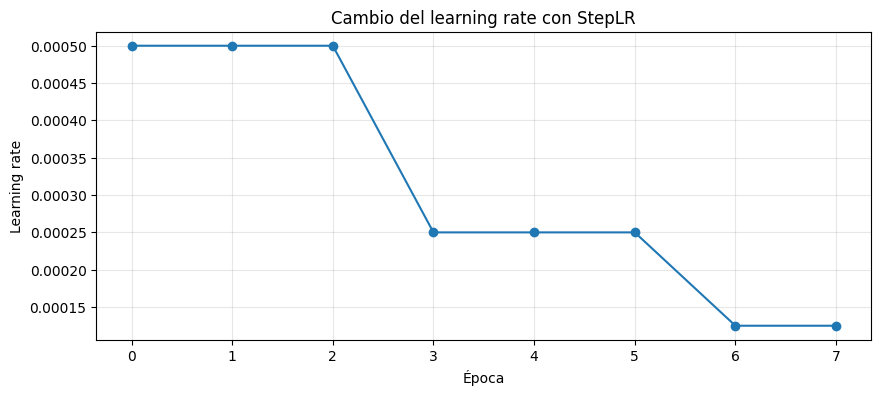

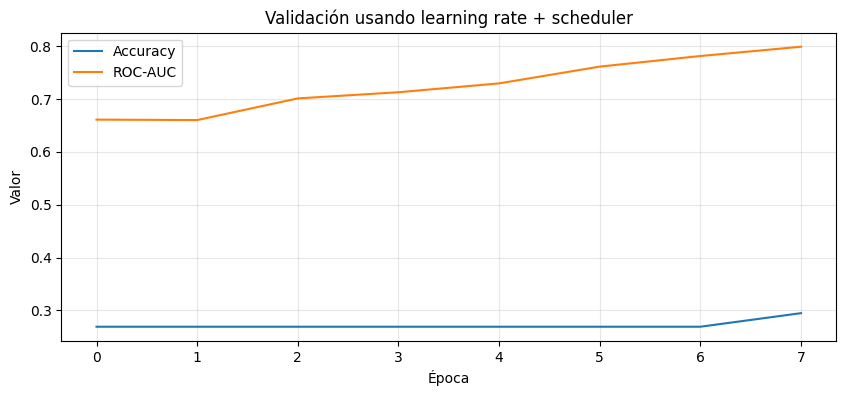

In [45]:
# Grafico cómo fue cambiando el learning rate y las métricas para ver el efecto del scheduler.
plt.figure(figsize=(10, 4))
plt.plot(history_scheduler["lr"], marker="o")
plt.title("Cambio del learning rate con StepLR")
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scheduler["val_acc"], label="Accuracy")
plt.plot(history_scheduler["val_auc"], label="ROC-AUC")
plt.title("Validación usando learning rate + scheduler")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [46]:
# Evalúo el modelo entrenado con scheduler para compararlo con los modelos anteriores.
test_acc_scheduler, test_auc_scheduler, _, _, _ = evaluate(
    model_scheduler,
    test_loader
)

print(f"CNN mejorada sin scheduler | Accuracy={test_acc_improved:.4f} | ROC-AUC={test_auc_improved:.4f}")
print(f"CNN mejorada con scheduler | Accuracy={test_acc_scheduler:.4f} | ROC-AUC={test_auc_scheduler:.4f}")


CNN mejorada sin scheduler | Accuracy=0.2692 | ROC-AUC=0.8133
CNN mejorada con scheduler | Accuracy=0.2885 | ROC-AUC=0.7928


### 11.3. Ejercicio 3: analizar diferentes aumentos de datos

Para este ejercicio comparo dos niveles de aumento:

- **Aumento suave:** cambios pequeños.
- **Aumento más fuerte:** rotaciones y desplazamientos un poco mayores.

Así puedo observar si modificar más las imágenes ayuda o perjudica al modelo.


In [47]:
# Creo dos tipos de Data Augmentation para comparar un aumento suave con uno más fuerte.
transform_aug_soft = T.Compose([
    T.RandomRotation(degrees=5),
    T.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    T.ToTensor()
])

transform_aug_strong = T.Compose([
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.10, 0.10)),
    T.ToTensor()
])

train_dataset_aug_soft = DataClass(
    split="train",
    transform=transform_aug_soft,
    download=True
)

train_dataset_aug_strong = DataClass(
    split="train",
    transform=transform_aug_strong,
    download=True
)

train_loader_aug_soft = DataLoader(
    train_dataset_aug_soft,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

train_loader_aug_strong = DataLoader(
    train_dataset_aug_strong,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


In [48]:
# Creo una función sencilla para entrenar el mismo modelo con cada tipo de aumento y hacer una comparación justa.
def train_for_augmentation(loader, epochs=6):
    model = SimpleCNN(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, loader, optimizer, criterion)
        val_acc, val_auc, _, _, _ = evaluate(model, val_loader)

        print(
            f"Epoch {epoch:02d} | "
            f"loss={train_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_auc={val_auc:.4f}"
        )

    return model


In [49]:
# Entreno un modelo con aumento suave y otro con aumento más fuerte.
print("=== Aumento suave ===")
model_aug_soft = train_for_augmentation(train_loader_aug_soft, epochs=6)

print("\n=== Aumento fuerte ===")
model_aug_strong = train_for_augmentation(train_loader_aug_strong, epochs=6)


=== Aumento suave ===
Epoch 01 | loss=0.6697 | val_acc=0.7308 | val_auc=0.5313
Epoch 02 | loss=0.6178 | val_acc=0.7308 | val_auc=0.5196
Epoch 03 | loss=0.6182 | val_acc=0.7308 | val_auc=0.5171
Epoch 04 | loss=0.5688 | val_acc=0.7308 | val_auc=0.5230
Epoch 05 | loss=0.5749 | val_acc=0.7308 | val_auc=0.5221
Epoch 06 | loss=0.5719 | val_acc=0.7308 | val_auc=0.5230

=== Aumento fuerte ===
Epoch 01 | loss=0.7226 | val_acc=0.5513 | val_auc=0.5038
Epoch 02 | loss=0.6584 | val_acc=0.7308 | val_auc=0.5322
Epoch 03 | loss=0.6098 | val_acc=0.7308 | val_auc=0.5263
Epoch 04 | loss=0.6016 | val_acc=0.7308 | val_auc=0.5313
Epoch 05 | loss=0.5593 | val_acc=0.7308 | val_auc=0.5305
Epoch 06 | loss=0.5652 | val_acc=0.7308 | val_auc=0.5330


In [50]:
# Evalúo los dos tipos de aumento y comparo sus resultados con el modelo sin Data Augmentation.
test_acc_soft, test_auc_soft, _, _, _ = evaluate(model_aug_soft, test_loader)
test_acc_strong, test_auc_strong, _, _, _ = evaluate(model_aug_strong, test_loader)

print(f"Sin aumento      | Accuracy={test_acc:.4f} | ROC-AUC={test_auc:.4f}")
print(f"Aumento original | Accuracy={test_acc_aug:.4f} | ROC-AUC={test_auc_aug:.4f}")
print(f"Aumento suave    | Accuracy={test_acc_soft:.4f} | ROC-AUC={test_auc_soft:.4f}")
print(f"Aumento fuerte   | Accuracy={test_acc_strong:.4f} | ROC-AUC={test_auc_strong:.4f}")


Sin aumento      | Accuracy=0.7308 | ROC-AUC=0.7364
Aumento original | Accuracy=0.7308 | ROC-AUC=0.5929
Aumento suave    | Accuracy=0.7308 | ROC-AUC=0.5850
Aumento fuerte   | Accuracy=0.7308 | ROC-AUC=0.5890


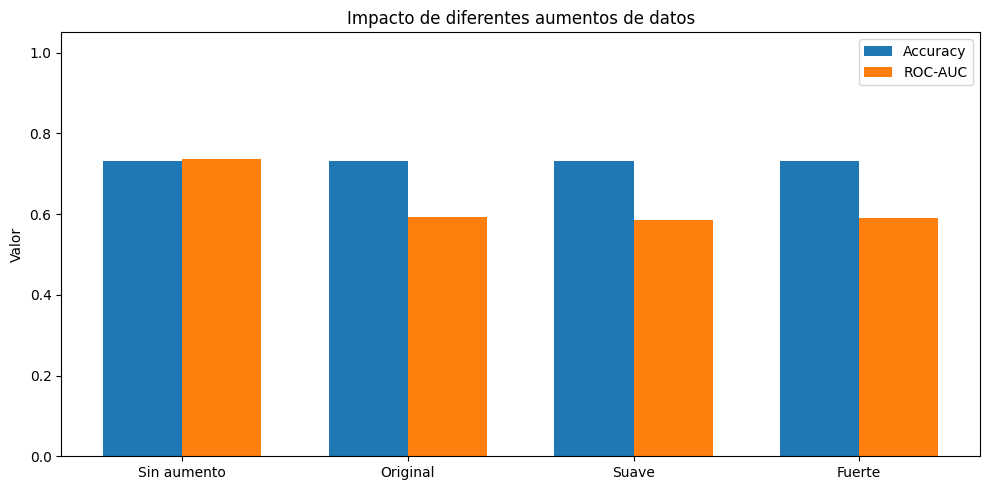

In [51]:
# Muestro una comparación gráfica para identificar fácilmente qué aumento obtuvo mejores resultados.
augmentation_names = [
    "Sin aumento",
    "Original",
    "Suave",
    "Fuerte"
]

augmentation_acc = [
    test_acc,
    test_acc_aug,
    test_acc_soft,
    test_acc_strong
]

augmentation_auc = [
    test_auc,
    test_auc_aug,
    test_auc_soft,
    test_auc_strong
]

x = np.arange(len(augmentation_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, augmentation_acc, width, label="Accuracy")
plt.bar(x + width/2, augmentation_auc, width, label="ROC-AUC")
plt.xticks(x, augmentation_names)
plt.ylim(0, 1.05)
plt.ylabel("Valor")
plt.title("Impacto de diferentes aumentos de datos")
plt.legend()
plt.tight_layout()
plt.show()


### 11.4. Ejercicio 4: cambiar el dataset dentro de MedMNIST

Este punto ya está realizado desde el inicio del notebook.

El notebook de ejemplo trabajaba con `pneumoniamnist`, mientras que en esta actividad cambié el pipeline a:

```python
data_flag = "breastmnist"
```

También adapté las etiquetas a:

- `0`: **Maligno**
- `1`: **Normal/Benigno**

Por eso este ejercicio ya queda cumplido con el tema de **ecografías de mama**.


### 11.5. Ejercicio 5: calibración de probabilidades y curvas ROC

Finalmente voy a revisar las probabilidades del modelo.

Para la calibración utilizo el conjunto de **validación** para ajustar una regresión logística sobre la salida de ResNet18.  
Después comparo las probabilidades originales y calibradas usando:

- **Brier Score**, donde un valor más bajo indica mejores probabilidades.
- **Curva de calibración**.
- **Curva ROC** y **ROC-AUC**.


In [52]:
# Creo una función para obtener la salida del modelo antes de convertirla en probabilidad, porque la usaré para calibrar ResNet18.
@torch.no_grad()
def collect_logit_scores(model, loader):
    model.eval()

    all_labels = []
    all_scores = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        # Para dos clases uso la diferencia entre el logit de la clase 1 y el de la clase 0.
        scores = logits[:, 1] - logits[:, 0]

        all_labels.append(y.cpu().numpy())
        all_scores.append(scores.cpu().numpy())

    return np.concatenate(all_labels), np.concatenate(all_scores)

y_val_cal, score_val_cal = collect_logit_scores(resnet, val_loader_tl)
y_test_cal, score_test_cal = collect_logit_scores(resnet, test_loader_tl)


In [53]:
# Ajusto una regresión logística con validación para calibrar las probabilidades y luego la aplico al conjunto de prueba.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_curve, auc
from sklearn.calibration import calibration_curve

calibrator = LogisticRegression()
calibrator.fit(score_val_cal.reshape(-1, 1), y_val_cal)

prob_test_calibrated = calibrator.predict_proba(
    score_test_cal.reshape(-1, 1)
)[:, 1]

brier_original = brier_score_loss(y_true_tl, y_prob_tl)
brier_calibrated = brier_score_loss(y_test_cal, prob_test_calibrated)

print(f"Brier Score original:  {brier_original:.4f}")
print(f"Brier Score calibrado: {brier_calibrated:.4f}")
print("Un Brier Score más bajo indica probabilidades mejor calibradas.")


Brier Score original:  0.0981
Brier Score calibrado: 0.0911
Un Brier Score más bajo indica probabilidades mejor calibradas.


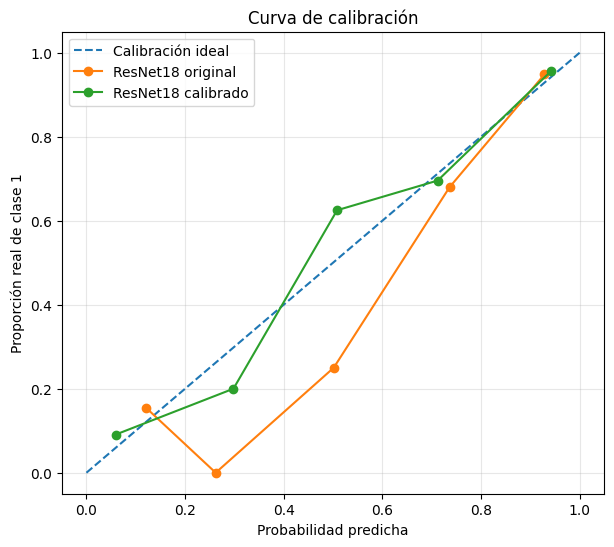

In [54]:
# Comparo las curvas de calibración antes y después de ajustar las probabilidades.
prob_true_original, prob_pred_original = calibration_curve(
    y_true_tl,
    y_prob_tl,
    n_bins=5,
    strategy="uniform"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test_cal,
    prob_test_calibrated,
    n_bins=5,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración ideal")
plt.plot(
    prob_pred_original,
    prob_true_original,
    marker="o",
    label="ResNet18 original"
)
plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="ResNet18 calibrado"
)

plt.xlabel("Probabilidad predicha")
plt.ylabel("Proporción real de clase 1")
plt.title("Curva de calibración")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


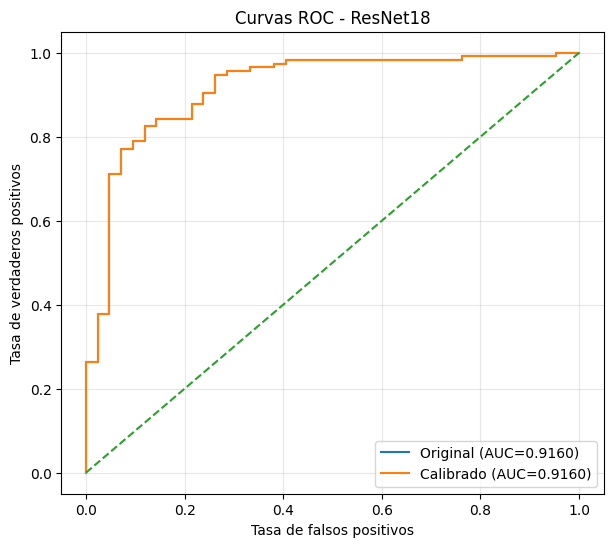

In [55]:
# Grafico las curvas ROC del modelo original y del modelo calibrado y calculo sus áreas bajo la curva.
fpr_original, tpr_original, _ = roc_curve(y_true_tl, y_prob_tl)
fpr_cal, tpr_cal, _ = roc_curve(y_test_cal, prob_test_calibrated)

auc_original = auc(fpr_original, tpr_original)
auc_calibrated = auc(fpr_cal, tpr_cal)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_original,
    tpr_original,
    label=f"Original (AUC={auc_original:.4f})"
)
plt.plot(
    fpr_cal,
    tpr_cal,
    label=f"Calibrado (AUC={auc_calibrated:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - ResNet18")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 12. Resumen final de la actividad

Con estos experimentos ya quedan desarrollados los puntos solicitados:

1. Se modificó la arquitectura agregando **BatchNorm, Dropout y más filtros**.
2. Se probó otro **learning rate** y un **scheduler**.
3. Se compararon diferentes niveles de **Data Augmentation**.
4. Se cambió el dataset a **BreastMNIST** y se adaptó todo el pipeline.
5. Se implementó **calibración de probabilidades** y se analizaron **curvas ROC**.

Los resultados pueden cambiar ligeramente cada vez que se entrene el notebook porque los pesos iniciales y los aumentos de datos contienen aleatoriedad.


In [56]:
# Muestro una tabla final con los principales modelos para tener un resumen de los resultados obtenidos en toda la actividad.
modelos_finales = [
    "CNN original",
    "CNN con augmentation",
    "CNN mejorada",
    "CNN mejorada + scheduler",
    "ResNet18 + fine-tuning"
]

accuracy_final = [
    test_acc,
    test_acc_aug,
    test_acc_improved,
    test_acc_scheduler,
    test_acc_tl
]

auc_final = [
    test_auc,
    test_auc_aug,
    test_auc_improved,
    test_auc_scheduler,
    test_auc_tl
]

print(f"{'Modelo':<30} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 54)

for nombre, acc_value, auc_value in zip(
    modelos_finales,
    accuracy_final,
    auc_final
):
    print(f"{nombre:<30} {acc_value:>10.4f} {auc_value:>10.4f}")


Modelo                           Accuracy    ROC-AUC
------------------------------------------------------
CNN original                       0.7308     0.7364
CNN con augmentation               0.7308     0.5929
CNN mejorada                       0.2692     0.8133
CNN mejorada + scheduler           0.2885     0.7928
ResNet18 + fine-tuning             0.8718     0.9160


In [57]:
# Guardo también los modelos nuevos que se crearon en los ejercicios para conservar todo el trabajo final.
os.makedirs("models", exist_ok=True)

torch.save(
    model_improved.state_dict(),
    "models/breast_cnn_improved.pth"
)

torch.save(
    model_scheduler.state_dict(),
    "models/breast_cnn_scheduler.pth"
)

torch.save(
    model_aug_soft.state_dict(),
    "models/breast_cnn_aug_soft.pth"
)

torch.save(
    model_aug_strong.state_dict(),
    "models/breast_cnn_aug_strong.pth"
)

print("Modelos adicionales guardados correctamente.")


Modelos adicionales guardados correctamente.
